# Standardization

By default MOOGP rescales the data internally before fitting:

  * `standardize_x="unitcube"` maps each input to `[-1, 1]` using the training
    min/max, so you can pass raw `X` to `fit` and `predict`.
  * `standardize_y="zscore"` centers and scales each output (mean / sample std);
    `"robust"` uses median / MAD instead.

Set either to `False` when your data is already on the right scale. **Predictions
are always returned on the original output scale**, regardless of these settings.

The kernel theory and the default length-scale bounds assume inputs live on the
unit cube, so standardizing `X` keeps a single set of defaults meaningful. This
notebook shows why each transform matters and when to disable it.

In [1]:
# !pip install moogp
# !pip install matplotlib

import numpy as np
import matplotlib.pyplot as plt

from moogp.model import MOOGP
from moogp import evaluation

## 1. `standardize_x`: pass raw inputs on any scale

MOOGP's default kernel bounds assume the inputs live on `[-1, 1]`, in particular,
each latent length-scale is constrained to `[0.05, 100]`. `standardize_x="unitcube"`
rescales `X` to that range using the training min/max (and applies the same map to
test inputs), so those bounds stay meaningful whatever units your data is in.

Below the inputs span 0 to 5000. With `"unitcube"` the model rescales internally and
recovers the smooth curve. With `standardize_x=False` the raw inputs keep their huge
scale, but the length-scale still can't grow past `100` — far shorter than the
200-unit gap between training points — so the GP only sees each point's tiny
neighborhood and snaps back to the linear trend in between.

standardize_x=unitcube   test RMSE = 0.016   fitted length-scale =   1.09  (bounds 0.05–100)
standardize_x=False      test RMSE = 0.115   fitted length-scale = 100.00  (bounds 0.05–100)

learned x center: [2500.]  half-width: [2750.]


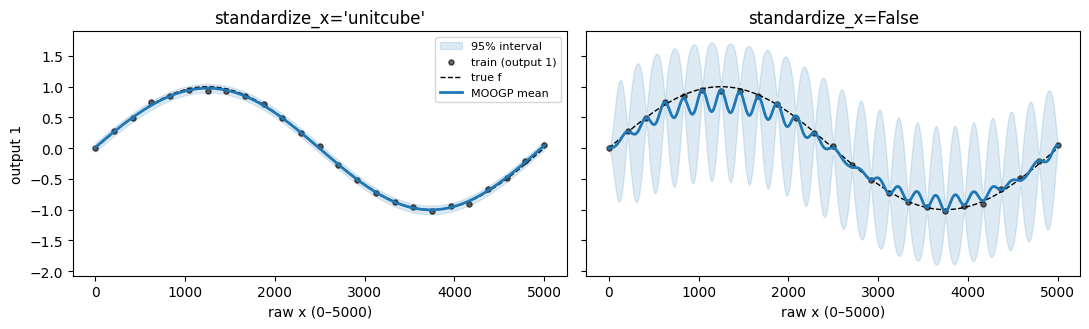

In [2]:
rng = np.random.default_rng(0)
n = 25
domain = 5000.0                                     # inputs on a large raw scale

X = np.linspace(0, domain, n).reshape(-1, 1)
def f(x):
    return np.sin(2 * np.pi * x / domain)           # one smooth period
Y = np.column_stack([f(X[:, 0]), 0.5 * f(X[:, 0]) + 2]) + rng.normal(0, 0.03, size=(n, 2))

X_te = np.linspace(0, domain, 400).reshape(-1, 1)
F_te = np.column_stack([f(X_te[:, 0]), 0.5 * f(X_te[:, 0]) + 2])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, sx in zip(axes, ["unitcube", False]):
    m = MOOGP(terms=[None, 1], q=1, standardize_x=sx, standardize_y="zscore")
    m.fit({"X": X, "Y": Y}, optimizer_opts={"maxiter": 400})
    pred, std = m.predict(X_te, return_std=True)
    ell = float(m.cache["lat_params"][0][1][0])      # the single latent length-scale
    print(f"standardize_x={str(sx):9s}  test RMSE = {evaluation.rmse(F_te, pred):.3f}"
          f"   fitted length-scale = {ell:6.2f}  (bounds 0.05–100)")
    ax.fill_between(X_te[:, 0], pred[:, 0] - 2 * std[:, 0], pred[:, 0] + 2 * std[:, 0],
                    color="tab:blue", alpha=0.15, label="95% interval")
    ax.scatter(X[:, 0], Y[:, 0], s=14, c="k", alpha=0.6, label="train (output 1)")
    ax.plot(X_te[:, 0], F_te[:, 0], "k--", lw=1, label="true f")
    ax.plot(X_te[:, 0], pred[:, 0], color="tab:blue", lw=2, label="MOOGP mean")
    ax.set_title(f"standardize_x={sx!r}")
    ax.set_xlabel("raw x (0–5000)")
axes[0].set_ylabel("output 1")
axes[0].legend(fontsize=8)
fig.tight_layout()

# The model records exactly how it rescaled the inputs, and reuses that map at predict time:
m = MOOGP(terms=[None, 1], q=1, standardize_x="unitcube")
m.fit({"X": X, "Y": Y}, optimizer_opts={"maxiter": 400})
print("\nlearned x center:", m.x_center_, " half-width:", m.x_scale_)

The fitted length-scale tells the whole story: `"unitcube"` settles at `1.09`,
comfortably inside the bounds, while `standardize_x=False` leaves it pinned at the
upper bound `100`. It wants to be larger to match the raw-scale data but isn't
allowed to. So with `"unitcube"` you hand raw `X` straight to `fit`/`predict` and the
default bounds still fit; with `standardize_x=False` you're promising MOOGP the
inputs are already on `[-1, 1]`, and feeding it large-scale `X` instead breaks the
fit. Either way, predictions come back on the original output scale.

## 2. `standardize_y`: outputs of very different magnitudes

`standardize_y="zscore"` puts every output on a common internal scale, so one set
of priors and bounds works whether an output is order `1e3` or `1e-2`. Below,
output 1 is ~1000× larger than output 2; without `standardize_y` the large output
dominates and fits worse.

In [3]:
rng = np.random.default_rng(0)
n = 60
x = np.linspace(0, 1, n).reshape(-1, 1)
shape = np.sin(2 * np.pi * x[:, 0])
F = np.column_stack([1000 * shape + 5000, 0.02 * shape + 0.05])   # very different scales
Y = F + rng.normal(0, 1, size=(n, 2)) * np.array([20.0, 0.001])

x_te = np.linspace(0, 1, 200).reshape(-1, 1)
shape_te = np.sin(2 * np.pi * x_te[:, 0])
F_te = np.column_stack([1000 * shape_te + 5000, 0.02 * shape_te + 0.05])

for sy in ["zscore", False]:
    m = MOOGP(terms=[None, 1], q=2, standardize_y=sy)
    m.fit({"X": x, "Y": Y}, optimizer_opts={"maxiter": 300})
    pred = m.predict(x_te)
    # Range-normalized RMSE makes the two outputs comparable.
    nrmse = [evaluation.rmse(F_te[:, j], pred[:, j]) / np.ptp(F_te[:, j]) for j in range(2)]
    print(f"standardize_y={str(sy):7s}  per-output normalized RMSE = {np.round(nrmse, 4)}")

standardize_y=zscore   per-output normalized RMSE = [0.0034 0.0065]
standardize_y=False    per-output normalized RMSE = [0.1714 0.0058]


## 3. `"robust"` standardization resists extreme values

`zscore` uses the mean and sample standard deviation; `robust` uses the median
and median-absolute-deviation (MAD). The robust scale is far less sensitive to a
few extreme values, which is useful for skewed or heavy-tailed outputs.

In [4]:
base = np.sin(np.linspace(0, 3, 80))
clean = base.copy()
contaminated = base.copy()
contaminated[:3] += 50.0   # a few extreme values

for label, col in [("clean", clean), ("with 3 extremes", contaminated)]:
    std = np.std(col, ddof=1)
    mad = np.median(np.abs(col - np.median(col)))
    print(f"{label:16s}  zscore scale (std) = {std:7.3f}   robust scale (MAD) = {mad:7.3f}")

clean             zscore scale (std) =   0.296   robust scale (MAD) =   0.230
with 3 extremes   zscore scale (std) =   9.440   robust scale (MAD) =   0.211


The standard-deviation scale jumps by ~30× when three extreme values are added,
while the MAD scale barely moves — so `standardize_y="robust"` keeps the internal
output scale stable in the presence of outliers.

### Takeaways

  * `standardize_x="unitcube"` (default) lets you pass raw inputs and keeps the
    default length-scale bounds meaningful; set `False` if `X` is already on
    `[-1, 1]`.
  * `standardize_y="zscore"` (default) handles outputs of very different
    magnitudes; `"robust"` resists extreme values; `False` disables scaling.
  * Predictions always come back on the original output scale.